# Nonlinear expressions

Nonlinear functions can describe relationships whose parameters have a direct interpretation,
such as a maximum reaction rate or a tree's final size.

Bambi lets us write these functions as formulas and model their parameters. We start with
enzyme kinetics, then use `nl(...)` to add treatment effects to a shared curve. A tree-growth
example shows how to let a nonlinear parameter vary by group.

In [1]:
# | code-fold: true
%config InlineBackend.figure_format = "retina"
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import arviz as az
import arviz_plots as azp
import arviz_stats as azs
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("bambi.mplstyle")


## Michaelis-Menten enzyme kinetics

The `Puromycin` dataset contains reaction rates measured at several substrate concentrations for
treated and untreated cells. It is described in the
[`datasets` documentation](https://search.r-project.org/R/refmans/datasets/html/Puromycin.html).

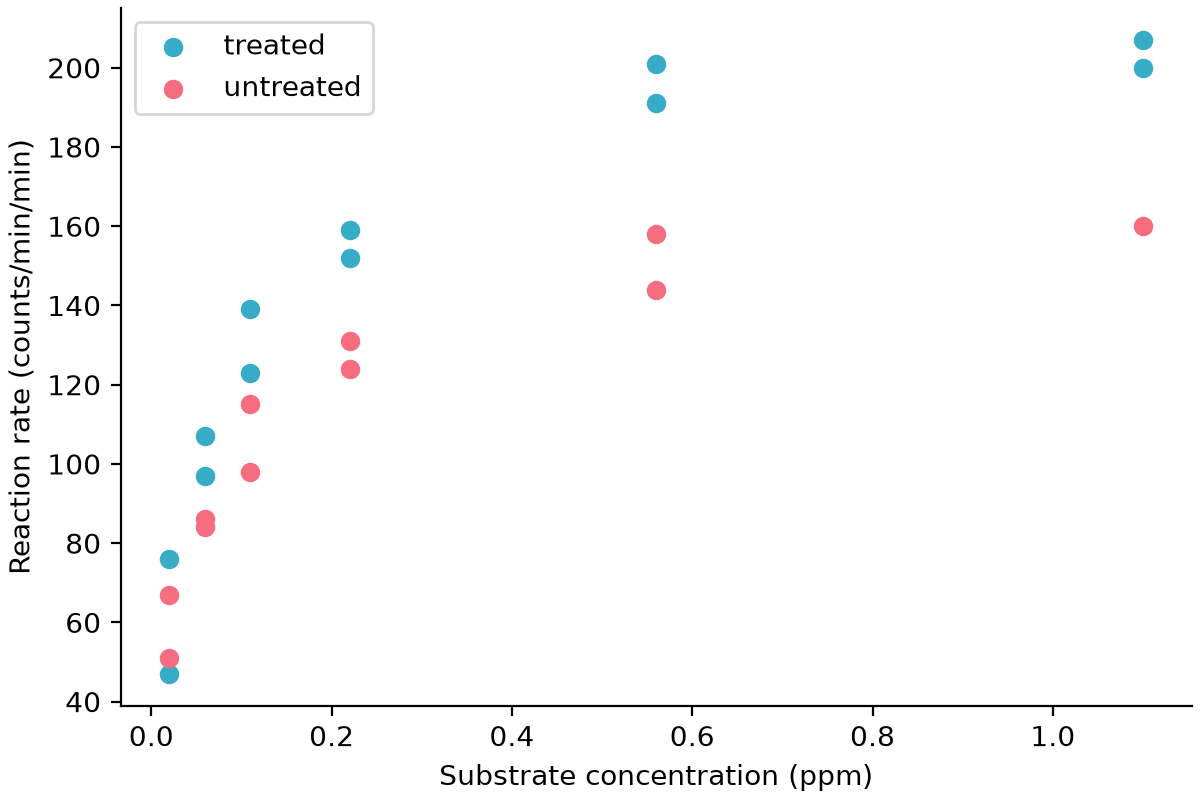

In [2]:
puromycin = pd.read_csv("data/puromycin.csv")
puromycin["state"] = puromycin["state"].astype("category")

for state, group in puromycin.groupby("state", observed=True):
    plt.scatter(group["concentration"], group["rate"], label=state)
plt.xlabel("Substrate concentration (ppm)")
plt.ylabel("Reaction rate (counts/min/min)")
plt.legend()
plt.show()

The Michaelis-Menten curve describes the expected reaction rate at substrate concentration $c_i$:

$$
\mu_i = \frac{V_{\max,i} c_i}{K_{m,i} + c_i}.
$$

$V_{\max}$ is the asymptotic rate, and $K_m$ is the concentration at half that rate.
Both parameters can differ between treated and untreated cells.

The first formula in the `bmb.Formula` call defines the nonlinear mean. The additional formulas describe how `vmax`
and `km` depend on treatment. Both names must also appear in `nlpars`. Here, `0 + state`
estimates one coefficient per treatment for each parameter.

We use a Gamma response because reaction rates are positive. With an identity link, the nonlinear formula gives the expected rate directly. The Gamma response allows more variation at higher mean rates. `alpha` controls this variation, with larger values giving less relative spread.

The `LogNormal` priors put the asymptote near 180 and half-saturation near 0.1 while keeping
both parameters positive. First, we check the implied rates before fitting.

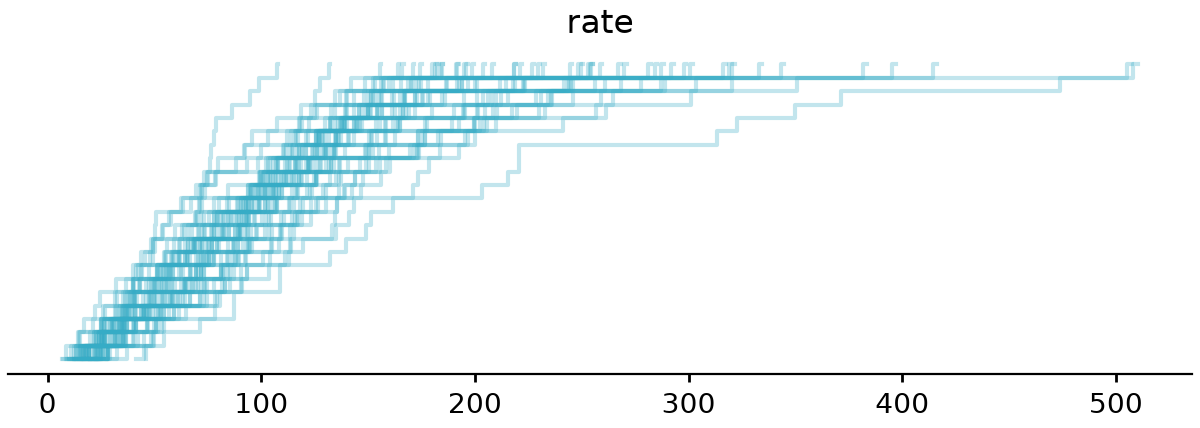

In [3]:
reaction_rate_expression = "vmax * concentration / (km + concentration)"
mm_formula = bmb.Formula(
    f"rate ~ {reaction_rate_expression}",
    "vmax ~ 0 + state",
    "km ~ 0 + state",
    nlpars=("vmax", "km"),
)
positive_priors = {
    "vmax": bmb.Prior("LogNormal", mu=np.log(180), sigma=0.25),
    "km": bmb.Prior("LogNormal", mu=np.log(0.1), sigma=0.4),
    "alpha": bmb.Prior("Gamma", alpha=2, beta=0.1),
}
mm_priors = {
    "vmax": {"state": positive_priors["vmax"]},
    "km": {"state": positive_priors["km"]},
    "alpha": positive_priors["alpha"],
}
puromycin_seed = sum(map(ord, "puromycin-model-comparison"))
mm_model = bmb.Model(
    mm_formula, puromycin, family="gamma", link="identity", priors=mm_priors
)
mm_model.build()
mm_prior = mm_model.prior_predictive(random_seed=puromycin_seed)
azp.plot_ppc_dist(
    mm_prior,
    group="prior_predictive",
    var_names=["rate"],
    backend="matplotlib",
)
plt.show()

The prior predictions span a broad range of rates. They are all positive, by our design. Next, we fit the model, check
sampling diagnostics, and summarize the parameters for each treatment.

In [4]:
mm_idata = mm_model.fit(
    draws=2000,
    tune=2000,
    inference_method="nutpie",
    random_seed=puromycin_seed,
    target_accept=0.95,
    progressbar=False,
)
azs.diagnose(mm_idata)
az.summary(
    mm_idata,
    var_names=["vmax_state", "km_state", "alpha"],
    ci_prob=0.94,
    ci_kind="hdi",
)

NUTS[nutpie]: [alpha, vmax_state, km_state]


Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
vmax_state[treated],208.8,14.3,180,240,3764,4364,1.00,0.23,0.19
vmax_state[untreated],163.2,11.9,140,180,2991,3712,1.00,0.22,0.17
km_state[treated],0.0564,0.0094,0.04,0.074,3745,4147,1.00,0.00015,0.00012
km_state[untreated],0.0454,0.0083,0.03,0.06,2886,3717,1.00,0.00016,0.00012
alpha,45,13.1,23,71,4524,4405,1.00,0.19,0.14


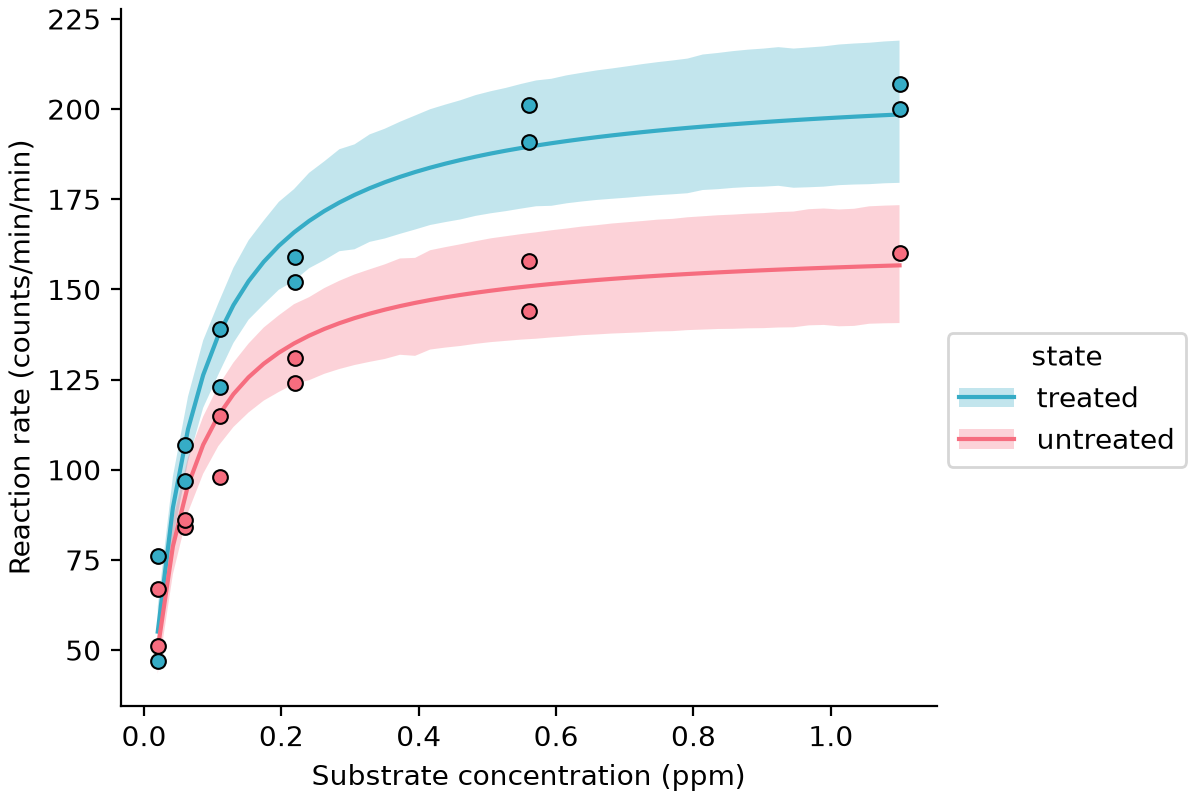

In [5]:
mm_fig = bmb.interpret.plot_predictions(
    mm_model,
    mm_idata,
    conditional=["concentration", "state"],
)
mm_ax = mm_fig.axes[0]
plot_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for (state, group), color in zip(
    puromycin.groupby("state", observed=True), plot_colors
):
    mm_ax.scatter(
        group["concentration"],
        group["rate"],
        facecolors=color,
        edgecolors="black",
        linewidths=0.75,
        s=28,
        zorder=3,
    )
mm_ax.set_xlabel("Substrate concentration (ppm)")
mm_ax.set_ylabel("Reaction rate (counts/min/min)")
mm_fig

The treated cells have a higher estimated asymptotic rate. Each curve has its own `vmax`
and `km`, so the difference between treatments can change with concentration.

### A nonlinear curve with additive treatment effects

An alternative model shares the nonlinear curve, letting treatment shift only the baseline:

$$
\mu_i = \beta_{\mathrm{state}[i]} + \frac{V_{\max} c_i}{K_m + c_i}.
$$

`nl(...)` adds the curve directly to the mean, without an extra coefficient.
Outside it, `0 + state` estimates one baseline per treatment and omits the global intercept.
Here `vmax` is the shared increase above baseline, so the asymptote is `baseline + vmax` and
`km` is the concentration at half that increase.

We keep the Gamma response, identity link, and kinetic priors from the first model, and use a `HalfNormal(30)` prior to keep each baseline positive.

In [6]:
mixed_formula = bmb.Formula(
    f"rate ~ 0 + nl({reaction_rate_expression}) + state",
    nlpars=("vmax", "km"),
)
mixed_model = bmb.Model(
    mixed_formula,
    puromycin,
    family="gamma",
    link="identity",
    priors={"state": bmb.Prior("HalfNormal", sigma=30), **positive_priors},
)
mixed_model.build()
mixed_prior = mixed_model.prior_predictive(random_seed=puromycin_seed)

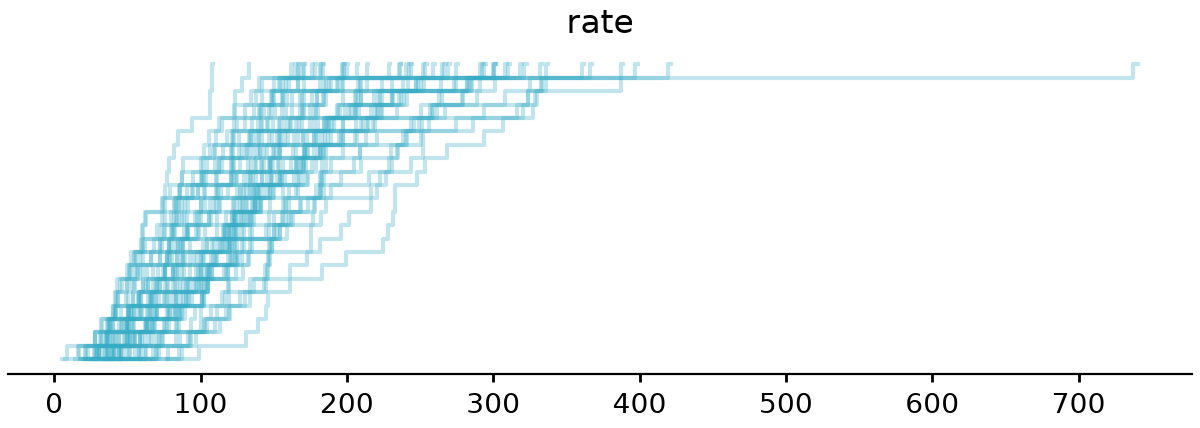

In [7]:
azp.plot_ppc_dist(
    mixed_prior,
    group="prior_predictive",
    var_names=["rate"],
    backend="matplotlib",
)
plt.show()

Even with the same kinetic priors, our prior predictive check differs from before - this is helpful understanding the range of values the model can support.

In [8]:
mixed_idata = mixed_model.fit(
    draws=2000,
    tune=2000,
    inference_method="nutpie",
    random_seed=puromycin_seed,
    target_accept=0.95,
    progressbar=False,
)
azs.diagnose(mixed_idata)
az.summary(
    mixed_idata,
    var_names=["state", "vmax", "km", "alpha"],
    ci_prob=0.94,
    ci_kind="hdi",
)

NUTS[nutpie]: [alpha, vmax, km, state]


Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
state[treated],37.2,10.4,17,56,1454,1687,1.00,0.28,0.19
state[untreated],23.5,9.1,5,39,1399,1411,1.00,0.24,0.15
vmax,165.6,12.6,140,190,3022,3367,1.00,0.23,0.16
km,0.098,0.0281,0.051,0.15,1583,1981,1.00,0.00068,0.00046
alpha,47.5,13.8,23,73,4367,3881,1.00,0.2,0.17


The shared-shape model uses both treatment groups to estimate one completely pooled `vmax` and `km`. The baselines remain separate, giving the curves
a constant vertical gap.

### Comparing the two models

We overlay the fitted curves to see what changes when treatment affects only the baseline.

It is worth noting, the matching priors have different meanings: `vmax` describes the _total_ asymptote in the
first model and an _increase above baseline_ in the additive model.

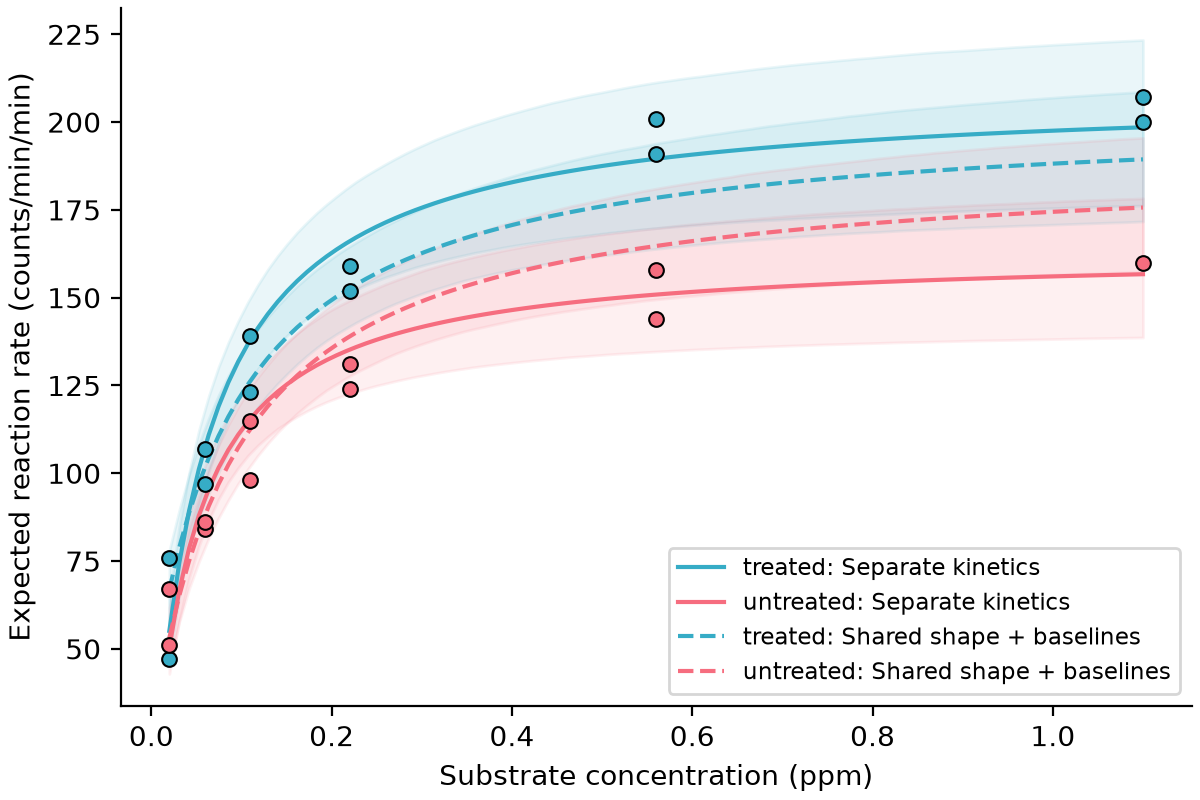

In [9]:
concentration_grid = np.linspace(
    puromycin["concentration"].min(), puromycin["concentration"].max(), 100
)
prediction_grid = pd.DataFrame(
    {
        "concentration": np.tile(concentration_grid, 2),
        "state": np.repeat(puromycin["state"].cat.categories, 100),
    }
)
comparison_fig, comparison_ax = plt.subplots()
for model, idata, label, linestyle in [
    (mm_model, mm_idata, "Separate kinetics", "-"),
    (mixed_model, mixed_idata, "Shared shape + baselines", "--"),
]:
    predicted = model.predict(idata, data=prediction_grid, inplace=False)
    mean_draws = predicted.predictions["mu"]
    for state, color in zip(puromycin["state"].cat.categories, plot_colors):
        state_draws = mean_draws.isel(__obs__=prediction_grid["state"] == state)
        mean = state_draws.mean(dim=("chain", "draw"))
        interval = state_draws.quantile([0.03, 0.97], dim=("chain", "draw"))
        comparison_ax.plot(
            concentration_grid,
            mean,
            color=color,
            linestyle=linestyle,
            label=f"{state}: {label}",
        )
        comparison_ax.fill_between(
            concentration_grid,
            interval.sel(quantile=0.03),
            interval.sel(quantile=0.97),
            color=color,
            alpha=0.1,
        )
for (state, group), color in zip(
    puromycin.groupby("state", observed=True), plot_colors
):
    comparison_ax.scatter(
        group["concentration"],
        group["rate"],
        color=color,
        edgecolors="black",
        linewidths=0.75,
        s=28,
        zorder=3,
    )
comparison_ax.set_xlabel("Substrate concentration (ppm)")
comparison_ax.set_ylabel("Expected reaction rate (counts/min/min)")
comparison_ax.legend(fontsize="small", loc="lower right")
plt.show()

At high concentrations, the shared-curve model tends to overshoot the untreated observations
and undershoot the treated ones. The visual comparison is less clear at low concentrations.

To compare predictive performance across all observations, we use leave-one-out expected log
predictive density (ELPD): how well each model predicts an observation when that observation
is left out of fitting. Higher ELPD is better. We use moment matching to improve the
leave-one-out approximation for influential observations.

In [10]:
# | code-fold: true
# | code-summary: "Compute the predictive comparison"
mm_model.compute_log_likelihood(mm_idata)
mixed_model.compute_log_likelihood(mixed_idata)
loo_models = {
    "Separate kinetics": az.loo(
        mm_idata,
        pointwise=True,
        moment_match=True,
        model=mm_model.backend.model,
    ),
    "Shared shape + baselines": az.loo(
        mixed_idata,
        pointwise=True,
        moment_match=True,
        model=mixed_model.backend.model,
    ),
}
comparison = az.compare(loo_models, round_to=2)
comparison[["elpd", "se", "elpd_diff", "dse"]]

/Volumes/T9/Projects/bambi-nonlinear-pr1002/.pixi/envs/py312/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/Volumes/T9/Projects/bambi-nonlinear-pr1002/.pixi/envs/py312/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,elpd,se,elpd_diff,dse
Shared shape + baselines,-99.04,3.86,0.00,0.0
Separate kinetics,-100.31,4.91,-1.28,5.3


The shared-shape model has _slightly_ higher leave-one-out ELPD,
a difference of **1.28 with a standard error of 5.30**. The uncertainty is large relative
to the difference, so there is no clear predictive winner under these likelihood and prior
choices.

### Predicting toward zero concentration

The models make different assumptions near zero: the first curve approaches zero, while
the additive curve approaches its treatment baseline. We can use `predict` to see this.
New data needs both `concentration` and `state`.

We focus on concentrations up to 0.11 ppm and start _just_ above zero, in order to not break the Gamma. 
The gray region lies below the lowest observed concentration (0.02 ppm), where both curves are extrapolations.

/var/folders/yp/g4z_ylx565j4hzgny6j2phtc0000gn/T/ipykernel_97922/1182074317.py:64: UserWarning: The figure layout has changed to tight
  zero_fig.tight_layout()


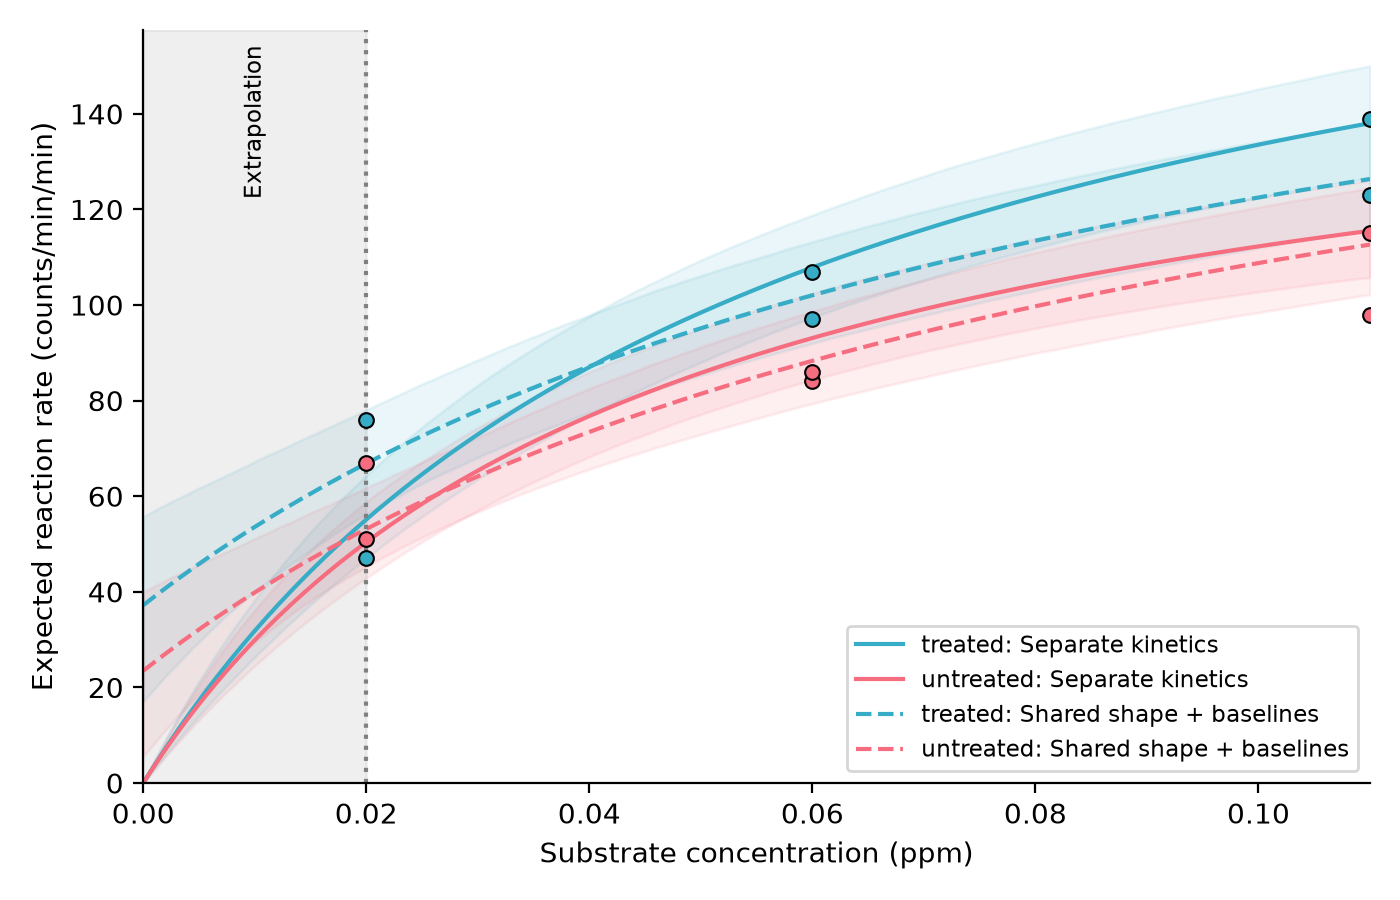

In [14]:
low_concentrations = np.linspace(1e-6, 0.11, 200)
new_data = pd.DataFrame(
    {
        "concentration": np.tile(low_concentrations, 2),
        "state": np.repeat(puromycin["state"].cat.categories, len(low_concentrations)),
    }
)
zero_fig, zero_ax = plt.subplots(figsize=(7, 4.5))
for model, idata, label, linestyle in [
    (mm_model, mm_idata, "Separate kinetics", "-"),
    (mixed_model, mixed_idata, "Shared shape + baselines", "--"),
]:
    predictions = model.predict(idata, data=new_data, inplace=False)
    for state, color in zip(puromycin["state"].cat.categories, plot_colors):
        mean_draws = predictions.predictions["mu"].isel(
            __obs__=new_data["state"] == state
        )
        interval = mean_draws.quantile([0.03, 0.97], dim=("chain", "draw"))
        zero_ax.plot(
            low_concentrations,
            mean_draws.mean(dim=("chain", "draw")),
            color=color,
            linestyle=linestyle,
            label=f"{state}: {label}",
        )
        zero_ax.fill_between(
            low_concentrations,
            interval.sel(quantile=0.03),
            interval.sel(quantile=0.97),
            color=color,
            alpha=0.1,
        )
for (state, group), color in zip(
    puromycin.groupby("state", observed=True), plot_colors
):
    group = group[group["concentration"] <= low_concentrations.max()]
    zero_ax.scatter(
        group["concentration"],
        group["rate"],
        color=color,
        edgecolors="black",
        linewidths=0.75,
        s=28,
        zorder=3,
    )
minimum_observed = puromycin["concentration"].min()
zero_ax.axvspan(0, minimum_observed, color="gray", alpha=0.12)
zero_ax.axvline(minimum_observed, color="gray", linestyle=":")
zero_ax.text(
    minimum_observed / 2,
    0.98,
    "Extrapolation",
    transform=zero_ax.get_xaxis_transform(),
    ha="center",
    va="top",
    rotation=90,
    fontsize="small",
)
zero_ax.set_xlim(0, low_concentrations.max())
zero_ax.set_ylim(bottom=0)
zero_ax.set_xlabel("Substrate concentration (ppm)")
zero_ax.set_ylabel("Expected reaction rate (counts/min/min)")
zero_ax.legend(fontsize="small", loc="lower right")
zero_fig.tight_layout()
plt.show()

The solid lines (for the separate kinetics model) approach zero, while the dashed lines approach the treatment baselines. This helps understand some of the assumptions and boundary behavior of the models we have put together.

## Logistic growth of orange trees

The treatment example used separate coefficients for two groups. We can also give a nonlinear
parameter a group-specific effect, so its estimates partially pool across groups.

The `Orange` dataset follows the trunk circumference of five trees at seven ages. Its
[`datasets` documentation](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/Orange.html)
uses a three-parameter logistic growth curve. We model circumference as

$$
y_{ij} = \frac{A_j}{1 + \exp((x_{\mathrm{mid}} - x_{ij})/s)} + \epsilon_{ij},
$$

where $A_j$ is tree $j$'s asymptotic circumference, $x_{\mathrm{mid}}$ is the age at half that
circumference, and $s$ controls the growth timescale. Here we use Gaussian observation noise.

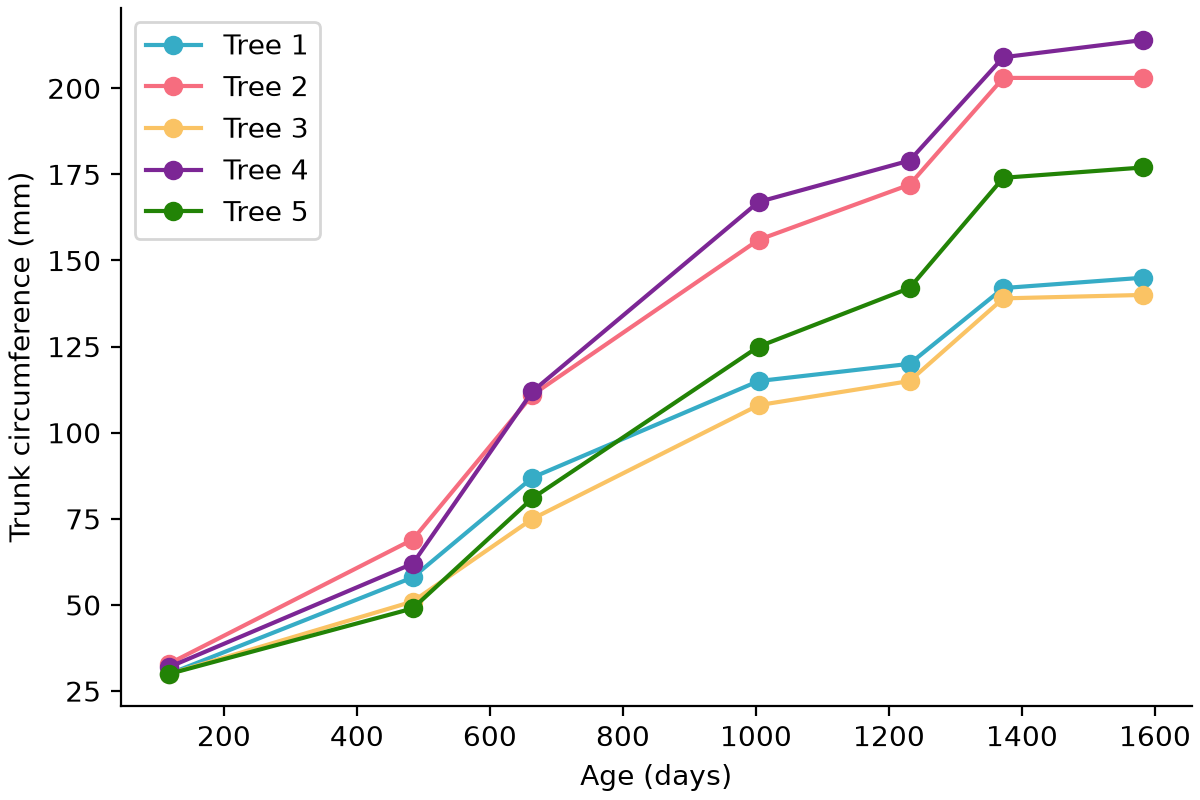

In [6]:
orange = pd.read_csv("data/orange.csv")
orange["age"] = orange["age"].astype(float)
orange["tree"] = orange["tree"].astype("category")

for tree, group in orange.groupby("tree", observed=True):
    plt.plot(group["age"], group["circumference"], "o-", label=f"Tree {tree}")
plt.xlabel("Age (days)")
plt.ylabel("Trunk circumference (mm)")
plt.legend()
plt.show()

The asymptote varies by tree through `asym ~ 1 + (1 | tree)`. Each tree has a deviation
from the shared intercept, while `xmid` and `scale` are common to all trees.

Parameters without an additional formula, such as `xmid` and `scale`, take direct priors
and are sampled under those names. An explicit `~ 1` formula gives the same model when
the prior matches.

In [7]:
growth_expression = "asym / (1 + exp((xmid - age) / scale))"
orange_formula = bmb.Formula(
    f"circumference ~ {growth_expression}",
    "asym ~ 1 + (1 | tree)",
    nlpars=("asym", "xmid", "scale"),
)

orange_priors = {
    "asym": {
        "Intercept": bmb.Prior("Normal", mu=190, sigma=30),
        "1|tree": bmb.Prior(
            "Normal",
            mu=0,
            sigma=bmb.Prior("HalfNormal", sigma=30),
        ),
    },
    "xmid": bmb.Prior("Normal", mu=700, sigma=200),
    "scale": bmb.Prior("LogNormal", mu=np.log(350), sigma=0.4),
    "sigma": bmb.Prior("HalfNormal", sigma=20),
}

orange_model = bmb.Model(orange_formula, orange, priors=orange_priors)
orange_idata = orange_model.fit(
    random_seed=123,
    target_accept=0.9,
    progressbar=False,
)

We plot the fitted mean curves over a grid of ages and overlay the observed circumferences.
The bands show uncertainty in the mean curves, not the spread of individual measurements.

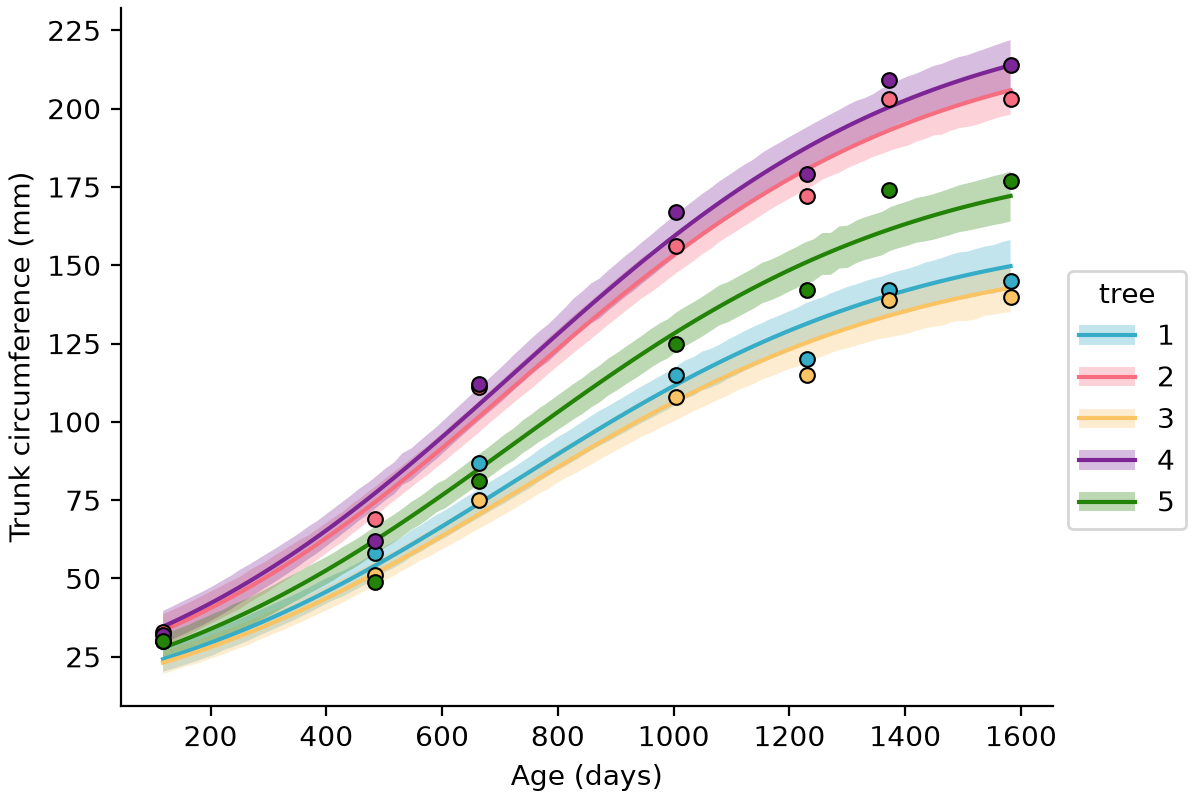

In [8]:
orange_fig = bmb.interpret.plot_predictions(
    orange_model,
    orange_idata,
    conditional={
        "age": np.linspace(orange["age"].min(), orange["age"].max(), 100),
        "tree": orange["tree"].cat.categories.tolist(),
    },
)
orange_ax = orange_fig.axes[0]
for (tree, group), color in zip(orange.groupby("tree", observed=True), plot_colors):
    orange_ax.scatter(
        group["age"],
        group["circumference"],
        facecolors=color,
        edgecolors="black",
        linewidths=0.75,
        s=28,
        zorder=3,
    )
orange_ax.set_xlabel("Age (days)")
orange_ax.set_ylabel("Trunk circumference (mm)")
orange_fig

## Composing model parameters

A modeled parameter can also appear inside another nonlinear expression, including one
for an auxiliary family parameter. The [golf putting example](golf_putting.ipynb) uses this
to make the Gaussian residual scale depend on the fitted success probability.